In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import pickle
import data_processing as dp

In [2]:
def gaussian(x, *p):
	A, mu, variance = p
	return A*np.exp(-(x-mu)**2/(2.*variance))
	
def iterative_gaussian_fit(bin_edges, data, core_width=1.5, tol=0.05):
	gaussians = []
	coeffs = []

	# gaussian fit to entire range
	bin_ctrs = (bin_edges[:-1] + bin_edges[1:]) / 2
	initial_coeff_guess = [np.max(data), bin_ctrs[np.argmax(data)], np.std(data)]
	coeff, _ = curve_fit(gaussian, bin_ctrs, data, p0=initial_coeff_guess)
	
	gaussian_xvals = np.linspace(bin_ctrs[0], bin_ctrs[-1], 1000)
	gaussians.append([gaussian_xvals, gaussian(gaussian_xvals, *coeff)])
	coeffs.append(coeff)

	iters = 0
	converged = False

	_, prev_mu, prev_variance = initial_coeff_guess
	_, mu, variance = coeff

	# reduce range until the tolerance is satisfied
	while iters < 100:
		iters += 1
		mask = (mu - core_width * np.sqrt(variance) < bin_ctrs) & (bin_ctrs < mu + core_width * np.sqrt(variance)) #+-core_width Sigma
		masked_data = data[mask]
		if len(masked_data) < 3: break
		masked_bin_ctrs = bin_ctrs[mask]

		# print(f"bin centers {masked_bin_ctrs}, data {masked_data}, coeff {coeff}"
		coeff, _ = curve_fit(gaussian, masked_bin_ctrs, masked_data, p0=coeff)
		prev_mu, prev_variance = mu, variance
		_, mu, variance = coeff
		if variance <= 0: print("hold up!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
		if abs((mu - prev_mu) / prev_mu) < tol and abs((variance - prev_variance) / prev_variance) < tol:
			# print(f"final iteration: mu={mu}, prev_mu={prev_mu}, sigma={sigma}. prev_sigma={prev_sigma}")
			converged = True
			break

	if not converged: print(f"Iterative Gaussian fit never converged. The algorithm may be oscillating between two fits that are not within the tolerance.")
	# print(mu-core_width*np.sqrt(variance), mu+core_width*np.sqrt(variance),"ok so  ",gaussian_xvals[1]-gaussian_xvals[0], 2*core_width*np.sqrt(variance))
	final_mask = (mu - core_width * np.sqrt(variance) < gaussian_xvals) & (gaussian_xvals < mu + core_width * np.sqrt(variance))

	return gaussian_xvals, final_mask, coeff



In [3]:
#Data path and data containers
# file_pattern = "/home/nstrobbe/mahon/hgcalmlSingularity/hgcal_minimal_eval_example/output/singlePhoton24-04-01/FTFP_BERT_EMN/*.pkl"
file_limit = 1000
species = "Pion"
sample = "nominal"
particleEnergy = "e50"

data, pass_noise_filter, out_gravnet = dp.load_data_bulk(sample, particleEnergy, species)
layer_positions = np.loadtxt("unique_z.txt")

true_cluster = np.array([ data[i].y for i in range(file_limit)], dtype=object) # real hits==1
final_pred_hits = np.array([ dp.process_gravnet(pass_noise_filter[i], out_gravnet[i]) for i in range(file_limit)], dtype=object) #real clusterHits>0

energy_true = np.array([ data[i].x[:,0][true_cluster[i]==1] for i in range(file_limit) ], dtype=object)
energy_reco = np.array([ data[i].x[:,0][final_pred_hits[i] > 0] for i in range(file_limit) ], dtype=object)

energy_reco_all = np.array([ data[i].x[:,0] for i in range(file_limit) ], dtype=object)

e_true_summed = np.asarray([np.sum(np.asarray(energy_true[i])) for i in range(file_limit)])
e_reco_summed = np.asarray([np.sum(np.asarray(energy_reco[i])) for i in range(file_limit)])
e_reco_summed_all = np.asarray([np.sum(np.asarray(energy_reco_all[i])) for i in range(file_limit)])

 

In [ ]:
# sigmoid = lambda x : (1+np.exp(-x)) ** (-1)
# print(out_gravnet[0][sigmoid(out_gravnet[0][:,0]) > 0.2].shape)
# print(len(energy_reco[0]))

# print(pass_noise_filter[0][pass_noise_filter[0]].shape)

[Data(x=[18369, 9], y=[18369], truth_cluster_props=[18369, 5], npz='/home/nstrobbe/mahon336/hgcalmlSingularity/hgcal_minimal_eval_example/singleTau24-11-25/step3_Tau_E50_n1000_part1_000_pos.npz', endcap='pos', batch=[18369]), Data(x=[18075, 9], y=[18075], truth_cluster_props=[18075, 5], npz='/home/nstrobbe/mahon336/hgcalmlSingularity/hgcal_minimal_eval_example/singleTau24-11-25/step3_Tau_E50_n1000_part1_001_pos.npz', endcap='pos', batch=[18075]), Data(x=[17964, 9], y=[17964], truth_cluster_props=[17964, 5], npz='/home/nstrobbe/mahon336/hgcalmlSingularity/hgcal_minimal_eval_example/singleTau24-11-25/step3_Tau_E50_n1000_part1_002_pos.npz', endcap='pos', batch=[17964]), Data(x=[18167, 9], y=[18167], truth_cluster_props=[18167, 5], npz='/home/nstrobbe/mahon336/hgcalmlSingularity/hgcal_minimal_eval_example/singleTau24-11-25/step3_Tau_E50_n1000_part1_003_pos.npz', endcap='pos', batch=[18167]), Data(x=[17899, 9], y=[17899], truth_cluster_props=[17899, 5], npz='/home/nstrobbe/mahon336/hgcalmlS

In [10]:
energy_len = np.array([ len(data[i].x[:,0][final_pred_hits[i] > 0]) for i in range(file_limit) ], dtype=object) 
energyT_len = np.array([ len(data[i].x[:,0][true_cluster[i]==1]) for i in range(file_limit) ], dtype=object)

Text(0.5, 1.0, 'tauZshift500cm event hit count')

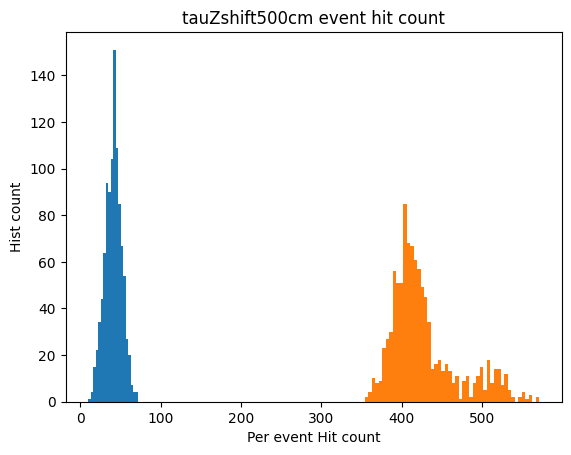

In [15]:
plt.hist(energy_len, bins=20)
plt.hist(energyT_len, bins=50)
plt.xlabel("Per event Hit count")
plt.ylabel("Hist count")
plt.title("tauZshift500cm event hit count")


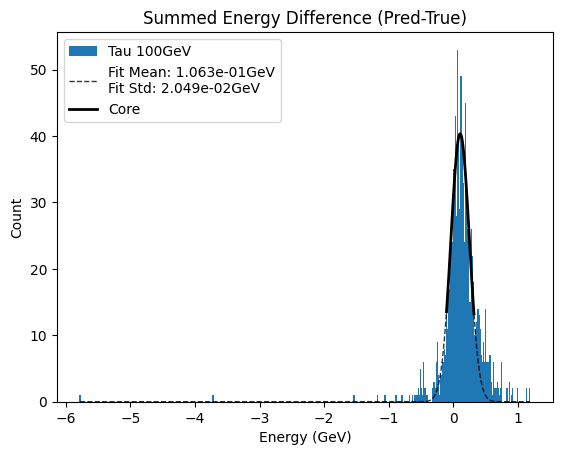

Iterative Gaussian fit never converged. The algorithm may be oscillating between two fits that are not within the tolerance.


/tmp/ipykernel_658124/2224789732.py:3: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-(x-mu)**2/(2.*variance))


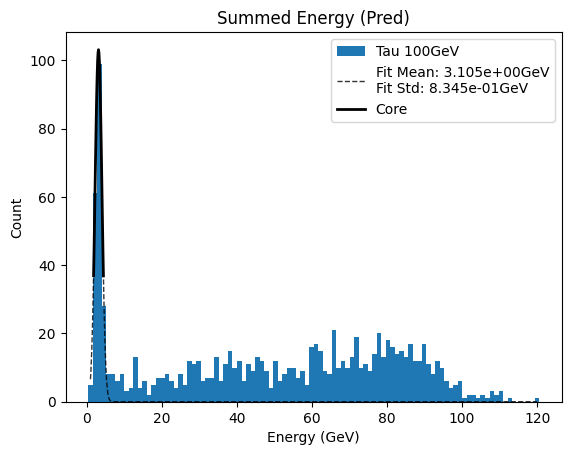

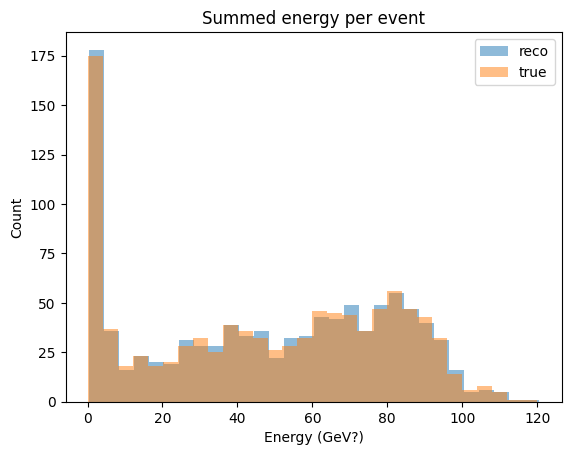

In [ ]:
ptdEn = int(particleEnergy[1:])
bins = 400

a = e_reco_summed-e_true_summed
hist_data, bin_edges = np.histogram(a,bins=bins)
gaussian_xvals, final_mask, coeff = iterative_gaussian_fit(bin_edges, hist_data, core_width = 1.5, tol = 0.50)
fig, ax = plt.subplots()
ax.hist(a,bins=bins, label=f"{species} {ptdEn}GeV")
ax.plot(gaussian_xvals, gaussian(gaussian_xvals,*coeff),"k--" , linewidth=1, label=f"Fit Mean: {coeff[1]:.3e}GeV\nFit Std: {(coeff[2])**0.5:.3e}GeV", alpha=0.8)
ax.plot(gaussian_xvals[final_mask], gaussian(gaussian_xvals[final_mask],*coeff), "k-", linewidth=2, alpha=1, label="Core")
# ax.set_xlim(-1.5,1.5)
ax.set_title("Summed Energy Difference (Pred-True)")
ax.set_xlabel("Energy (GeV)")
ax.set_ylabel("Count")
ax.legend()
plt.show()

bins2 = 100
b = e_reco_summed
hist_data2, bin_edges2 = np.histogram(b,bins=bins2)
gaussian_xvals2, final_mask2, coeff2 = iterative_gaussian_fit(bin_edges2, hist_data2, core_width = 1.5, tol = 0.10)
fig2, ax2 = plt.subplots()
ax2.hist(b,bins=bins2, label=f"{species} {ptdEn}GeV")
ax2.plot(gaussian_xvals2, gaussian(gaussian_xvals2,*coeff2),"k--" , linewidth=1, label=f"Fit Mean: {coeff2[1]:.3e}GeV\nFit Std: {(coeff2[2])**0.5:.3e}GeV", alpha=0.8)
ax2.plot(gaussian_xvals2[final_mask2], gaussian(gaussian_xvals2[final_mask2],*coeff2), "k-", linewidth=2, alpha=1, label="Core")
# ax.set_xlim(-1.5,1.5)
ax2.set_title("Summed Energy (Pred)")
ax2.set_xlabel("Energy (GeV)")
ax2.set_ylabel("Count")
ax2.legend()
plt.show()

plt.hist(e_reco_summed, bins=30, alpha=0.5, label="reco")
plt.hist(e_true_summed, bins=30, alpha=0.5, label="true")
plt.xlabel("Energy (GeV?)")
plt.ylabel("Count")
plt.title("Summed energy per event")
plt.legend()
plt.show()

# fig,ax = plt.subplots()
# ax.hist(a, bins=250, label=f"Mean {np.mean(a):.3f}GeV, STD {np.std(a):.3f}GeV")
# ax.set_xlim(-0.05,0.05)
# ax.legend()
# ax.set_ylabel("Count")
# ax.set_xlabel("Energy (GeV?)")
# ax.set_title("(E_reco - E_true) / e_true")

In [5]:
c = pd.DataFrame({"species": species, "sample":sample, "ptdEn":ptdEn, "mean":coeff[1], "std":coeff[2], "center":coeff[0]}, index=[0])
d = pd.DataFrame({"species": species, "sample":sample, "ptdEn":ptdEn, "mean":coeff2[1], "std":coeff2[2], "center":coeff2[0]}, index=[0])

with open("tempSummed.pkl",'rb') as file:
    d1 = pickle.load(file)

with open("tempDiffSummed.pkl",'rb') as file:
    c1 = pickle.load(file)

print(c1)
print(c)
print(d1)
print(d)


  species   sample  ptdEn      mean       std      center
0     Tau  nominal     50  0.068007  0.007147   58.232913
0     Tau  nominal     10  0.112140  0.010039   36.918146
0    Pion  nominal     50  0.177774  0.056697   61.601612
0    Pion  nominal     10  0.065592  0.015526  160.813245
0    Pion  nominal    100  0.280185  0.093323   64.573360
0    Kaon  nominal     10  0.185978  0.023770   41.079186
0    Kaon  nominal     50  0.299639  0.084524   32.203875
0    Kaon  nominal    100  0.240037  0.094817   26.068717
0     Tau  nominal     10  0.115184  0.010728   54.733812
  species   sample  ptdEn      mean       std     center
0     Tau  nominal    100  0.106324  0.020486  40.347415
  species   sample  ptdEn       mean        std     center
0     Tau  nominal     10   3.551654  18.929609  27.525518
0    Pion  nominal     50  44.537731  22.647060  63.556334
0    Pion  nominal     10   8.211517   3.703493  94.771470
0    Pion  nominal    100  90.880367  77.940539  60.859759
0    Kaon  

In [6]:

with open("tempSummed.pkl",'wb') as file:
    pickle.dump(pd.concat([d1,d]),file)
with open("tempDiffSummed.pkl",'wb') as file:
    pickle.dump(pd.concat([c1,c]),file)

  species   sample  ptdEn       mean        std     center
0    Kaon  nominal     10   8.166337   3.553946  90.826907
0    Kaon  nominal     50  44.388842  24.622156  61.127762
0    Kaon  nominal    100  90.907495  47.551361  65.726543
[1.88519132 4.96207172 6.89574945]


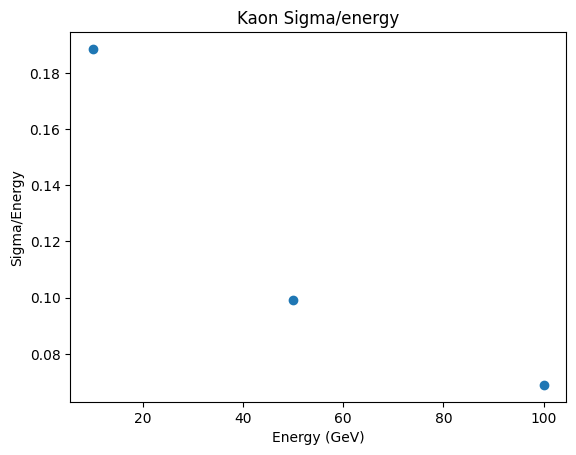

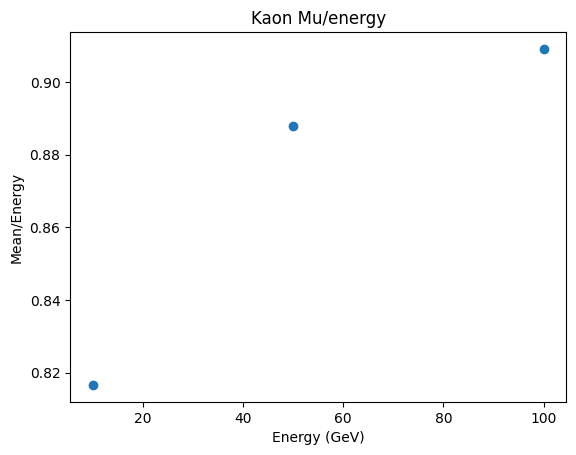

In [9]:
with open("tempSummed.pkl",'rb') as file:
    d1 = pickle.load(file)

with open("tempDiffSummed.pkl",'rb') as file:
    c1 = pickle.load(file)

eventSpe = "Kaon"

# c2 = c1.loc[c1["species"]==eventSpe]
# print(c2)
# ens = list(c2["ptdEn"])
# sigs = list(c2["std"])
# mu = list(c2["mean"])

# plt.scatter(ens,np.asarray(sigs)/np.asarray(ens))
# plt.xlabel("Energy (GeV)")
# plt.ylabel("Sigma/Energy")
# plt.title(f"{eventSpe} Difference Energy Resolution")
# plt.show()

# plt.scatter(ens,np.asarray(mu)/np.asarray(ens))
# plt.xlabel("Energy (GeV)")
# plt.ylabel("Mean/Energy")
# plt.title(f"{eventSpe} Difference Mu/Energy")
# plt.show()

d2 = d1.loc[d1["species"]==eventSpe]
print(d2)
ens = list(d2["ptdEn"])
vars = list(d2["std"])
sigs = np.asarray(vars)**0.5
mu = list(d2["mean"])
print(sigs)

plt.scatter(ens,np.asarray(sigs)/np.asarray(ens))
plt.xlabel("Energy (GeV)")
plt.ylabel("Sigma/Energy")
plt.title(f"{eventSpe} Sigma/energy")
plt.show()

plt.scatter(ens,np.asarray(mu)/np.asarray(ens))
plt.xlabel("Energy (GeV)")
plt.ylabel("Mean/Energy")
plt.title(f"{eventSpe} Mu/energy")
plt.show()
